# Nama: Rahman Nendhiarto
# Nim:  2200018315


Import Library.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.style.use("fivethirtyeight")

Representasikan teks ke dalam data numerik

In [ ]:
simple_train = ['call you tonight', 'Call me a cab', 'Please call me... PLEASE!']
from sklearn.feature_extraction.text import CountVectorizer
vect = CountVectorizer()
vect.fit(simple_train)
vect.get_feature_names_out()

array(['cab', 'call', 'me', 'please', 'tonight', 'you'], dtype=object)

Transformasi data uji ke dokumen term matrix

In [ ]:
simple_train_dtm = vect.transform(simple_train)
print(simple_train_dtm)
simple_train_dtm.toarray()

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 9 stored elements and shape (3, 6)>
  Coords	Values
  (0, 1)	1
  (0, 4)	1
  (0, 5)	1
  (1, 0)	1
  (1, 1)	1
  (1, 2)	1
  (2, 1)	1
  (2, 2)	1
  (2, 3)	2


array([[0, 1, 0, 0, 1, 1],
       [1, 1, 1, 0, 0, 0],
       [0, 1, 1, 2, 0, 0]])

Buat matrix dokumen

In [ ]:
pd.DataFrame(simple_train_dtm.toarray(),
columns=vect.get_feature_names_out())

,cab,call,me,please,tonight,you
0,0,1,0,0,1,1
1,1,1,1,0,0,0
2,0,1,1,2,0,0


Uji Sparse Matrix konten

In [ ]:
print(type(simple_train_dtm))
print(simple_train_dtm)

<class 'scipy.sparse._csr.csr_matrix'>
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 9 stored elements and shape (3, 6)>
  Coords	Values
  (0, 1)	1
  (0, 4)	1
  (0, 5)	1
  (1, 0)	1
  (1, 1)	1
  (1, 2)	1
  (2, 1)	1
  (2, 2)	1
  (2, 3)	2


Cek model tes

In [ ]:
simple_test = ["please don't call me"]

Transformasi data test ke dokumen term matrix

In [ ]:
simple_test_dtm = vect.transform(simple_test)
simple_test_dtm.toarray()
pd.DataFrame(simple_test_dtm.toarray(),
columns=vect.get_feature_names_out())

,cab,call,me,please,tonight,you
0,0,1,1,1,0,0


Membaca Dataset

In [ ]:
import pandas as pd
from google.colab import drive
from IPython.display import display
drive.mount('/content/drive')

file_path = '/content/drive/My Drive/prakpola/dataset_prak9/spam.csv'

sms = pd.read_csv(file_path, encoding='latin-1')

sms.dropna(how="any", inplace=True, axis=1)
sms.columns = ['label', 'message']

# Menampilkan hasil jika file berhasil dimuat
print("Berhasil memuat file! Berikut 5 baris pertama dari data:")
display(sms.head())

print("\nDeskripsi Statistik Data:")
display(sms.describe())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Berhasil memuat file! Berikut 5 baris pertama dari data:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



Deskripsi Statistik Data:


,label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


Konversi label ke variabel numerik

In [ ]:
sms['label_num'] = sms.label.map({'ham':0, 'spam':1})
sms.head()
sms['message_len'] = sms.message.apply(len)
sms.head()

,label,message,label_num,message_len
0,ham,"Go until jurong point, crazy.. Available only ...",0,111
1,ham,Ok lar... Joking wif u oni...,0,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,155
3,ham,U dun say so early hor... U c already then say...,0,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,61


Gambar figure Kalimat

Text(0.5, 0, 'Message Length')

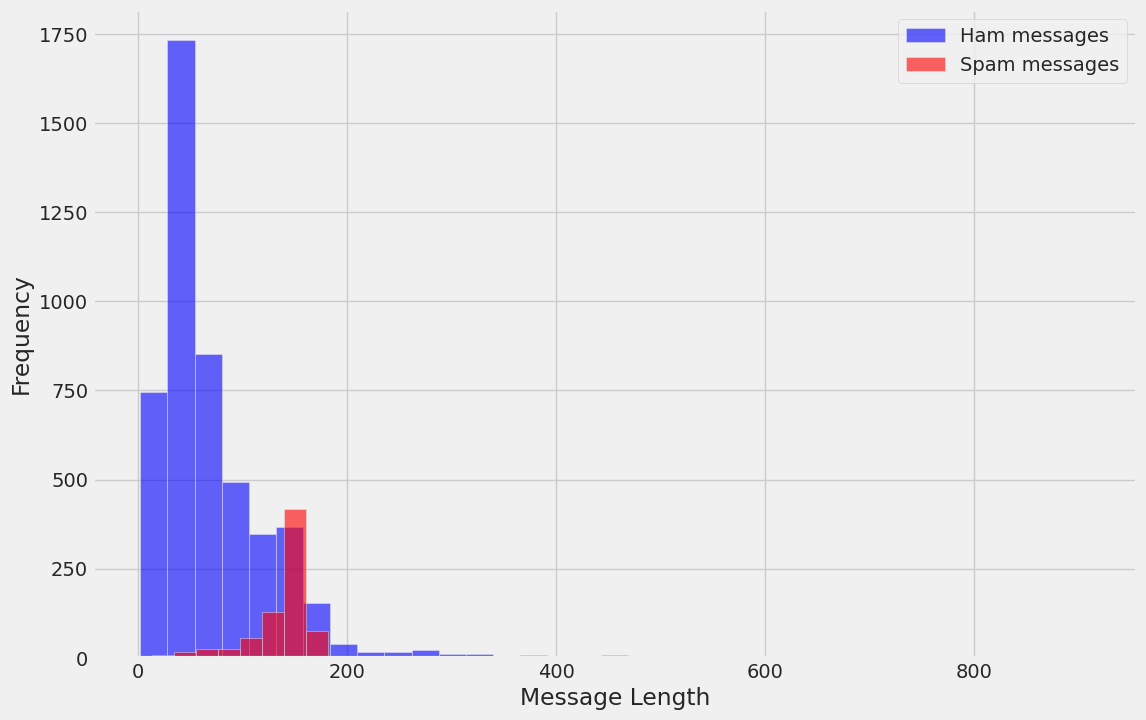

In [ ]:
plt.figure(figsize=(12, 8))
sms[sms.label=='ham'].message_len.plot(bins=35, kind='hist',
color='blue',
label='Ham messages', alpha=0.6)
sms[sms.label=='spam'].message_len.plot(kind='hist', color='red',
label='Spam messages', alpha=0.6)
plt.legend()
plt.xlabel("Message Length")

Cek label Ham dan Spam

In [ ]:
sms[sms.label=='ham'].describe()
sms[sms.label=='spam'].describe()
sms[sms.message_len == 910].message.iloc[0]

"For me the love should start with attraction.i should feel that I need her every time around me.she should be the first thing which comes in my thoughts.I would start the day and end it with her.she should be there every time I dream.love will be then when my every breath has her name.my life should happen around her.my life will be named to her.I would cry for her.will give all my happiness and take all her sorrows.I will be ready to fight with anyone for her.I will be in love when I will be doing the craziest things for her.love will be when I don't have to proove anyone that my girl is the most beautiful lady on the whole planet.I will always be singing praises for her.love will be when I start up making chicken curry and end up makiing sambar.life will be the most beautiful then.will get every morning and thank god for the day because she is with me.I would like to say a lot..will tell later.."

Pra Pemrosesan Pesan

In [ ]:
import string
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from collections import Counter

# Fungsi untuk memproses teks
def text_process(mess):
    STOPWORDS = stopwords.words('english') + ['u', 'ü', 'ur', '4', '2', 'im', 'dont', 'doin', 'ure']
    # Check characters to see if they are in punctuation
    nopunc = [char for char in mess if char not in string.punctuation]
    # Join the characters again to form the string.
    nopunc = ''.join(nopunc)
    # Now just remove any stopwords
    return ' '.join([word for word in nopunc.split() if word.lower() not in STOPWORDS])

# Tampilkan beberapa data awal
sms.head()

# Proses pembersihan teks dan simpan ke kolom baru
sms['clean_msg'] = sms['message'].apply(text_process)

# Tampilkan hasil setelah dibersihkan
sms.head()

# Tampilkan stopwords bahasa Inggris
stopwords.words('english')

# Hitung kata pada pesan HAM
words = sms[sms['label'] == 'ham']['clean_msg'].apply(lambda x: [word.lower() for word in x.split()])
ham_words = Counter()
for msg in words:
    ham_words.update(msg)
print(ham_words.most_common(50))

# Hitung kata pada pesan SPAM
words = sms[sms['label'] == 'spam']['clean_msg'].apply(lambda x: [word.lower() for word in x.split()])
spam_words = Counter()
for msg in words:
    spam_words.update(msg)
print(spam_words.most_common(50))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


[('get', 303), ('ltgt', 276), ('ok', 272), ('go', 247), ('ill', 236), ('know', 232), ('got', 231), ('like', 229), ('call', 229), ('come', 224), ('good', 222), ('time', 189), ('day', 187), ('love', 185), ('going', 167), ('want', 163), ('one', 162), ('home', 160), ('lor', 160), ('need', 156), ('sorry', 153), ('still', 146), ('see', 137), ('n', 134), ('later', 134), ('da', 131), ('r', 131), ('back', 129), ('think', 128), ('well', 126), ('today', 125), ('send', 123), ('tell', 121), ('cant', 118), ('ì', 117), ('hi', 117), ('take', 112), ('much', 112), ('oh', 111), ('night', 107), ('hey', 106), ('happy', 105), ('great', 100), ('way', 100), ('hope', 99), ('pls', 98), ('work', 96), ('wat', 95), ('thats', 94), ('dear', 94)]
[('call', 347), ('free', 216), ('txt', 150), ('mobile', 123), ('text', 120), ('claim', 113), ('stop', 113), ('reply', 101), ('prize', 92), ('get', 83), ('new', 69), ('send', 67), ('nokia', 65), ('urgent', 63), ('cash', 62), ('win', 60), ('contact', 56), ('service', 55), ('pl

Vektorisasi Pesan

In [ ]:
# Split X and y into training and testing sets
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

# Tentukan X dan y dari DataFrame sms
X = sms['clean_msg']
y = sms['label_num']

# Tampilkan bentuk (shape) dari X dan y
print("X shape:", X.shape)
print("y shape:", y.shape)

# Bagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

# Tampilkan bentuk data setelah split
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Inisialisasi CountVectorizer
vect = CountVectorizer()

# Fit dan transform X_train menjadi dokumen-term matrix (DTM)
X_train_dtm = vect.fit_transform(X_train)

# Tampilkan tipe dan bentuk DTM hasil pelatihan
print("X_train_dtm type and shape:", type(X_train_dtm), X_train_dtm.shape)

# Transformasi X_test menggunakan vocabulary yang telah dipelajari dari X_train
X_test_dtm = vect.transform(X_test)
print("X_test_dtm type and shape:", type(X_test_dtm), X_test_dtm.shape)

# Inisialisasi dan fit TF-IDF transformer ke data latih
tfidf_transformer = TfidfTransformer()
tfidf_transformer.fit(X_train_dtm)

# Transformasi data latih menjadi representasi TF-IDF
X_train_tfidf = tfidf_transformer.transform(X_train_dtm)


X shape: (5572,)
y shape: (5572,)
X_train shape: (4179,)
X_test shape: (1393,)
y_train shape: (4179,)
y_test shape: (1393,)
X_train_dtm type and shape: <class 'scipy.sparse._csr.csr_matrix'> (4179, 7996)
X_test_dtm type and shape: <class 'scipy.sparse._csr.csr_matrix'> (1393, 7996)


Evaluasi Model

In [ ]:
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
%time nb.fit(X_train_dtm, y_train)
from sklearn import metrics
# make class predictions for X_test_dtm
y_pred_class = nb.predict(X_test_dtm)
# calculate accuracy of class predictions
print("=======Accuracy Score===========")
print(metrics.accuracy_score(y_test, y_pred_class))
# print the confusion matrix
print("=======Confision Matrix===========")
metrics.confusion_matrix(y_test, y_pred_class)
X_test[y_pred_class > y_test]
# print message text for false negatives (spam incorrectly classifier)
X_test[y_pred_class < y_test]
# example of false negative
X_test[4949]
# calculate predicted probabilities for X_test_dtm (poorly calibrated)
y_pred_prob = nb.predict_proba(X_test_dtm)[:, 1]
y_pred_prob
# calculate AUC
metrics.roc_auc_score(y_test, y_pred_prob)
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.pipeline import Pipeline
pipe = Pipeline([('bow', CountVectorizer()),
('tfid', TfidfTransformer()),
('model', MultinomialNB())])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
# calculate accuracy of class predictions
print("=======Accuracy Score===========")
print(metrics.accuracy_score(y_test, y_pred))
# print the confusion matrix
print("=======Confision Matrix===========")
metrics.confusion_matrix(y_test, y_pred)
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(solver='liblinear')
# train the model using X_train_dtm
%time logreg.fit(X_train_dtm, y_train)
y_pred_class = logreg.predict(X_test_dtm)
# calculate predicted probabilities for X_test_dtm (well calibrated)
y_pred_prob = logreg.predict_proba(X_test_dtm)[:, 1]
y_pred_prob
print("=======Accuracy Score===========")
print(metrics.accuracy_score(y_test, y_pred_class))
# print the confusion matrix
print("=======Confusion Matrix===========")
print(metrics.confusion_matrix(y_test, y_pred_class))
# calculate AUC
print("=======ROC AUC Score===========")
print(metrics.roc_auc_score(y_test, y_pred_prob))

CPU times: user 2.13 ms, sys: 7 µs, total: 2.13 ms
Wall time: 5.28 ms
=======Accuracy Score===========
0.9827709978463748
=======Confision Matrix===========
=======Accuracy Score===========
0.9669777458722182
=======Confision Matrix===========
CPU times: user 12.3 ms, sys: 0 ns, total: 12.3 ms
Wall time: 12.4 ms
=======Accuracy Score===========
0.9842067480258435
=======Confusion Matrix===========
[[1213    0]
 [  22  158]]
=======ROC AUC Score===========
0.9835714940001832


# **POSTEST**

# Ketentuan
Klasifikasikan 3 pesan teks dari dataset "spam.csv" menggunakan model klasifikasi spam yang sudah ada, tentukan apakah setiap pesan adalah Spam atau Ham, dan jelaskan alasan di balik setiap prediksi berdasarkan isi pesan.

## 1. Pilih pesan

### Subtask:
Pilih 3 pesan teks dari dataset `sms` untuk diklasifikasikan. Pastikan untuk memilih pesan yang memiliki label asli (ham atau spam) untuk perbandingan.


In [ ]:
# Choose 3 indices for classification
selected_indices = [0, 2, 5571] # Example indices

# Get the original messages and labels for the selected indices
selected_messages = sms.loc[selected_indices, 'message']
selected_labels = sms.loc[selected_indices, 'label']

# Display the selected messages and their original labels
print("Selected messages and their original labels:")
for i, idx in enumerate(selected_indices):
    print(f"Index {idx}: Message - '{selected_messages.iloc[i]}', Original Label - '{selected_labels.iloc[i]}'")


Selected messages and their original labels:
Index 0: Message - 'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...', Original Label - 'ham'
Index 2: Message - 'Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's', Original Label - 'spam'
Index 5571: Message - 'Rofl. Its true to its name', Original Label - 'ham'


## 2. Pra pemrosesan pesan

### Subtask:
Terapkan fungsi `text_process` yang sudah ada pada 3 pesan yang dipilih untuk membersihkan teksnya.


In [ ]:
import string
import nltk
from nltk.corpus import stopwords
from collections import Counter

# Define the text_process function as it was defined previously
def text_process(mess):
    STOPWORDS = stopwords.words('english') + ['u', 'ü', 'ur', '4', '2', 'im', 'dont', 'doin', 'ure']
    # Check characters to see if they are in punctuation
    nopunc = [char for char in mess if char not in string.punctuation]
    # Join the characters again to form the string.
    nopunc = ''.join(nopunc)
    # Now just remove any stopwords
    return ' '.join([word for word in nopunc.split() if word.lower() not in STOPWORDS])

# Apply the text_process function to the selected_messages
cleaned_messages = selected_messages.apply(text_process)

# Print the cleaned messages
print("Cleaned messages:")
print(cleaned_messages)

Cleaned messages:
0       Go jurong point crazy Available bugis n great ...
2       Free entry wkly comp win FA Cup final tkts 21s...
5571                                       Rofl true name
Name: message, dtype: object


## 3. Vektorisasi pesan

### Subtask:
Gunakan `CountVectorizer` dan `TfidfTransformer` yang sudah dilatih pada data pelatihan (`X_train`) untuk mengubah 3 pesan yang sudah dibersihkan menjadi representasi numerik (DTM dan TF-IDF).


In [ ]:
# Use the trained CountVectorizer to transform cleaned_messages into a DTM
cleaned_messages_dtm = vect.transform(cleaned_messages)

# Use the trained TfidfTransformer to transform cleaned_messages_dtm into TF-IDF representation
cleaned_messages_tfidf = tfidf_transformer.transform(cleaned_messages_dtm)

# Print the shape of the resulting matrices to verify the transformation
print("Shape of cleaned_messages_dtm:", cleaned_messages_dtm.shape)
print("Shape of cleaned_messages_tfidf:", cleaned_messages_tfidf.shape)

Shape of cleaned_messages_dtm: (3, 7996)
Shape of cleaned_messages_tfidf: (3, 7996)


## 4. Klasifikasi pesan

### Subtask:
Gunakan model `logreg` yang sudah dilatih untuk memprediksi label (spam atau ham) untuk 3 pesan yang sudah divaktorisasi.


In [ ]:
# Predict the class labels (0 or 1) for the vectorized messages
predicted_labels = logreg.predict(cleaned_messages_dtm)

# Predict the class probabilities for the vectorized messages and get the probability for the positive class (spam, index 1)
predicted_probabilities = logreg.predict_proba(cleaned_messages_dtm)[:, 1]

# Print the predicted labels and probabilities
print("Predicted Labels:", predicted_labels)
print("Predicted Probabilities:", predicted_probabilities)

Predicted Labels: [0 1 0]
Predicted Probabilities: [0.004264   0.99689345 0.02824587]


## 4. Menjelaskan prediksi

### Subtask:
Bandingkan hasil prediksi model dengan label asli (jika ada) dan jelaskan alasan di balik prediksi model berdasarkan konten pesan yang sudah dibersihkan. Identifikasi kata-kata kunci atau pola yang mungkin mempengaruhi klasifikasi.


In [ ]:
classification_results = []

for i in range(len(selected_messages)):
    original_message = selected_messages.iloc[i]
    original_label = selected_labels.iloc[i]
    cleaned_message = cleaned_messages.iloc[i]
    predicted_label_num = predicted_labels[i]
    predicted_label = 'spam' if predicted_label_num == 1 else 'ham'

    explanation = f"Original label: {original_label}, Predicted label: {predicted_label}. "

    # Analyze cleaned message for keywords
    cleaned_words = cleaned_message.split()
    ham_keywords_in_message = [word for word in cleaned_words if word in ham_words and ham_words[word] > 50] # Using a threshold for common words
    spam_keywords_in_message = [word for word in cleaned_words if word in spam_words and spam_words[word] > 50] # Using a threshold for common words

    if original_label == predicted_label:
        explanation += "Model prediction matches the original label. "
        if predicted_label == 'ham':
            explanation += f"The message contains common ham keywords such as: {', '.join(ham_keywords_in_message)}. " if ham_keywords_in_message else "No prominent ham keywords found. "
        else: # predicted_label == 'spam'
             explanation += f"The message contains common spam keywords such as: {', '.join(spam_keywords_in_message)}. " if spam_keywords_in_message else "No prominent spam keywords found. "
    else:
        explanation += "Model prediction does NOT match the original label. "
        if predicted_label == 'ham':
             explanation += f"The message contains common ham keywords such as: {', '.join(ham_keywords_in_message)}, but was originally labeled as spam. " if ham_keywords_in_message else "No prominent ham keywords found, but was originally labeled as spam. "
        else: # predicted_label == 'spam'
            explanation += f"The message contains common spam keywords such as: {', '.join(spam_keywords_in_message)}, but was originally labeled as ham. " if spam_keywords_in_message else "No prominent spam keywords found, but was originally labeled as ham. "


    classification_results.append({
        "Original Message": original_message,
        "Original Label": original_label,
        "Cleaned Message": cleaned_message,
        "Predicted Label": predicted_label,
        "Explanation": explanation
    })

# Display the results
for result in classification_results:
    print("---")
    print("Original Message:", result["Original Message"])
    print("Original Label:", result["Original Label"])
    print("Cleaned Message:", result["Cleaned Message"])
    print("Predicted Label:", result["Predicted Label"])
    print("Explanation:", result["Explanation"])


---
Original Message: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Original Label: ham
Cleaned Message: Go jurong point crazy Available bugis n great world la e buffet Cine got amore wat
Predicted Label: ham
Explanation: Original label: ham, Predicted label: ham. Model prediction matches the original label. The message contains common ham keywords such as: n, great, e, got, wat. 
---
Original Message: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Original Label: spam
Cleaned Message: Free entry wkly comp win FA Cup final tkts 21st May 2005 Text FA 87121 receive entry questionstd txt rateTCs apply 08452810075over18s
Predicted Label: spam
Explanation: Original label: spam, Predicted label: spam. Model prediction matches the original label. The message contains common spam keywords such as: win, txt. 
---
Original 

## 5. Menyajikan hasil

### Subtask:
Sajikan 3 pesan asli, label aslinya, label prediksi dari model, dan penjelasan untuk setiap prediksi.


In [ ]:
for result in classification_results:
    print("---")
    print("Original Message:", result["Original Message"])
    print("Original Label:", result["Original Label"])
    print("Predicted Label:", result["Predicted Label"])
    print("Explanation:", result["Explanation"])

---
Original Message: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Original Label: ham
Predicted Label: ham
Explanation: Original label: ham, Predicted label: ham. Model prediction matches the original label. The message contains common ham keywords such as: n, great, e, got, wat. 
---
Original Message: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Original Label: spam
Predicted Label: spam
Explanation: Original label: spam, Predicted label: spam. Model prediction matches the original label. The message contains common spam keywords such as: win, txt. 
---
Original Message: Rofl. Its true to its name
Original Label: ham
Predicted Label: ham
Explanation: Original label: ham, Predicted label: ham. Model prediction matches the original label. No prominent ham keywords found. 


Text(0.5, 0, 'Message Length')

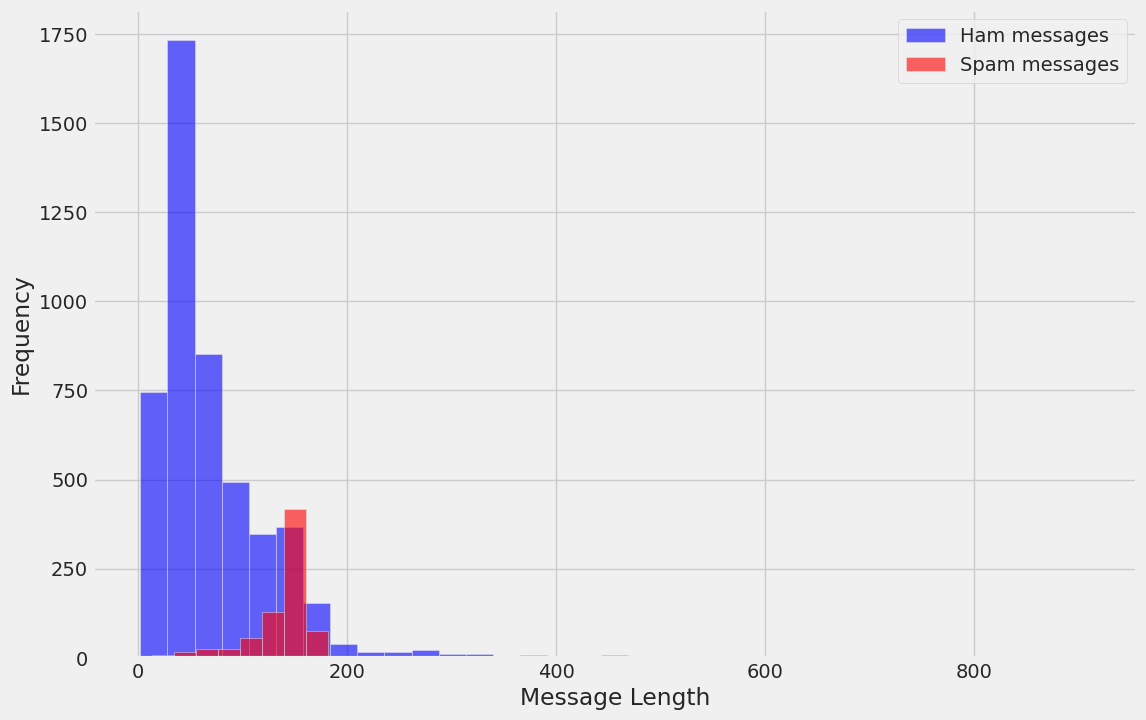

In [ ]:
plt.figure(figsize=(12, 8))
sms[sms.label=='ham'].message_len.plot(bins=35, kind='hist',
color='blue',
label='Ham messages', alpha=0.6)
sms[sms.label=='spam'].message_len.plot(kind='hist', color='red',
label='Spam messages', alpha=0.6)
plt.legend()
plt.xlabel("Message Length")